In [2]:
import numpy as np 
import pandas as pd 
import os
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.10.0


In [3]:
# Create a list with the filepaths for training and testing
train_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

In [4]:
test_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/valid')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [7]:
def image_processing(filepath):
    labels = [str(filepath[i]).split("\\")[-2] \
        for i in range(len(filepath))]
    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    df = pd.concat([filepath, labels], axis=1)
    df = df.sample(frac=1).reset_index(drop = True)
    return df

In [8]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [9]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 5415

Number of different labels: 58

Labels: ['Sandwich' 'Shak-Vaji' 'Sondesh' 'Chicken_curry' 'Biriyani'
 'Payesh-Firni' 'pizza' 'Shik_kabab' 'Singgara' 'Alu Bhorta'
 'Chitoi  Pitha' 'Prawn curry - Chingri bhuna' 'Misti'
 'kebab - Gosht Kebab' 'French_fries' 'Jalebi' 'Begun Bhorta' 'Borhani'
 'Fried_rice' 'Mixed vegetable stir-fry - Torkari' 'Salad'
 'Fish Bhuna_Mach Bhuna' 'Cake' 'Noodles' 'Boiled_egg' 'Begun Bhaja'
 'cheesecake' 'Vegetable fritters - Beguni' 'Momo' 'cup_cakes' 'omelette'
 'Falooda' 'Meat Curry_Gosht Bhuna' 'Lal-shak-Vaji' 'Chicken_wings'
 'Parata' 'Chocolate_cake' 'Kacchi' 'Doi' 'Fuchka' 'ice_cream' 'Alu-Vaji'
 'Chicken_Grill' 'Rosogolla' 'Fried chicken - Murg Bhaja'
 'Lentil soup_Dal' 'Burger' 'Khichuri' 'Hilsha_Fish_Curry' 'Shawarma'
 'poached_egg' 'Korola-Vaji' 'Tundul ruti - Nan Ruti' 'Vapa Pitha'
 'Fried fish_Mach Bhaja' 'Shemai' 'Lentil fritters - Dal Puri' 'Jorda']


In [11]:
train_df.head(58)

,Filepath,Label
0,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Sandwich
1,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Shak-Vaji
2,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Sondesh
3,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_curry
4,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Biriyani
5,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Payesh-Firni
6,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza
7,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza
8,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Shik_kabab
9,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza


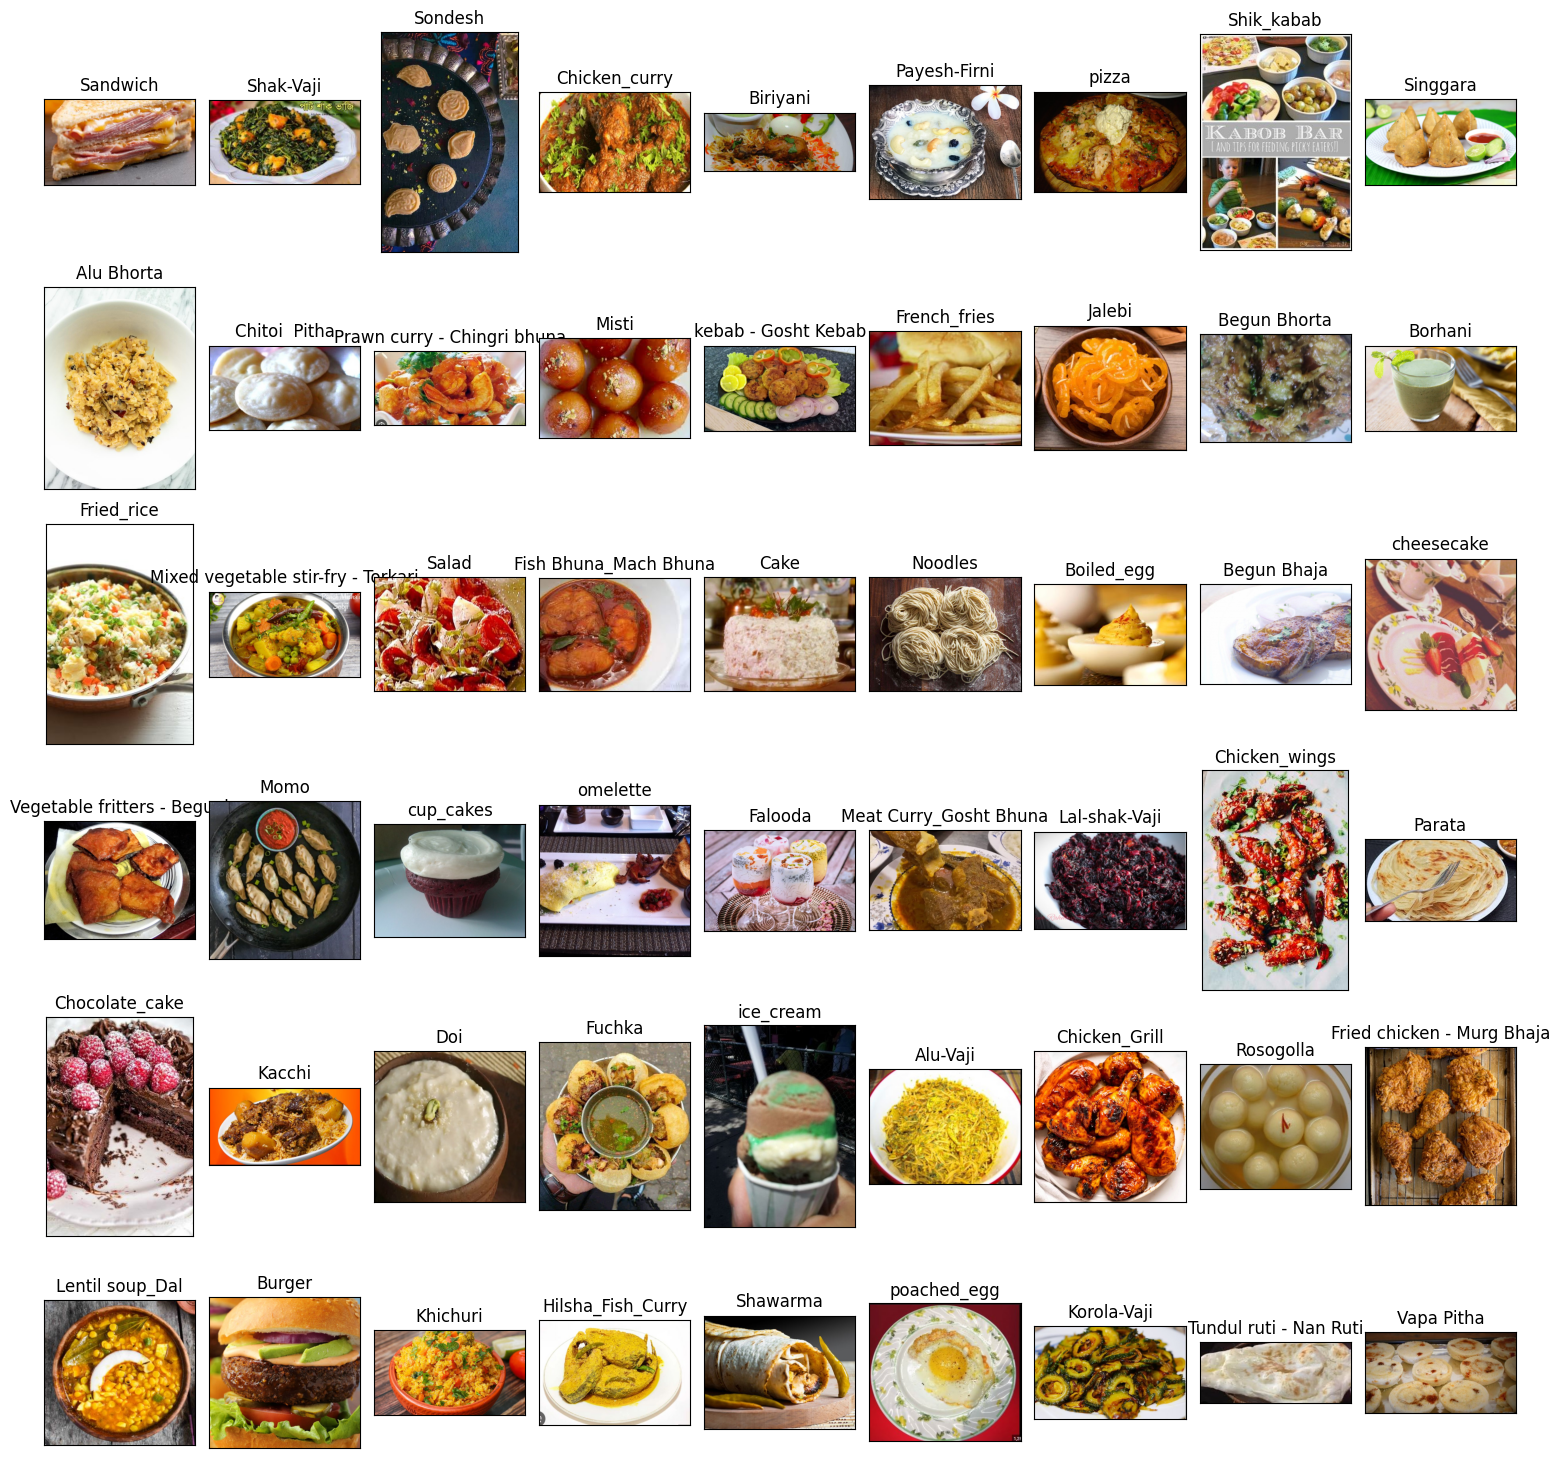

In [20]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=9, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=1)
plt.show()

In [21]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [22]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 5415 validated image filenames belonging to 58 classes.


In [23]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 272 validated image filenames belonging to 58 classes.


In [24]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 272 validated image filenames belonging to 58 classes.


In [25]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

In [26]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(58, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=5,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/5
170/170 [==============================] - 32s 140ms/step - loss: 2.2216 - accuracy: 0.4343 - val_loss: 1.6116 - val_accuracy: 0.5441
Epoch 2/5
170/170 [==============================] - 19s 110ms/step - loss: 0.8999 - accuracy: 0.7346 - val_loss: 1.2837 - val_accuracy: 0.6213
Epoch 3/5
170/170 [==============================] - 18s 108ms/step - loss: 0.5674 - accuracy: 0.8297 - val_loss: 1.1527 - val_accuracy: 0.6691
Epoch 4/5
170/170 [==============================] - 19s 109ms/step - loss: 0.3805 - accuracy: 0.8914 - val_loss: 1.1259 - val_accuracy: 0.6949
Epoch 5/5
170/170 [==============================] - 19s 111ms/step - loss: 0.2372 - accuracy: 0.9370 - val_loss: 1.0958 - val_accuracy: 0.7243


In [27]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

9/9 [==============================] - 2s 112ms/step


['Borhani',
 'Chicken_curry',
 'Boiled_egg',
 'Shak-Vaji',
 'Mixed vegetable stir-fry - Torkari',
 'Doi',
 'Shemai',
 'Doi',
 'omelette',
 'Chocolate_cake',
 'Salad',
 'Fish Bhuna_Mach Bhuna',
 'Chicken_curry',
 'ice_cream',
 'Begun Bhaja',
 'Noodles',
 'Meat Curry_Gosht Bhuna',
 'Biriyani',
 'Shemai',
 'Fried chicken - Murg Bhaja',
 'ice_cream',
 'Mixed vegetable stir-fry - Torkari',
 'Vapa Pitha',
 'Momo',
 'cup_cakes',
 'Rosogolla',
 'Doi',
 'omelette',
 'cheesecake',
 'Biriyani',
 'Biriyani',
 'Misti',
 'Noodles',
 'Sondesh',
 'cup_cakes',
 'Shemai',
 'cup_cakes',
 'Sandwich',
 'Alu-Vaji',
 'ice_cream',
 'Rosogolla',
 'Fried fish_Mach Bhaja',
 'Chitoi  Pitha',
 'French_fries',
 'Alu Bhorta',
 'Meat Curry_Gosht Bhuna',
 'Prawn curry - Chingri bhuna',
 'Begun Bhorta',
 'Alu Bhorta',
 'Chicken_Grill',
 'Boiled_egg',
 'Boiled_egg',
 'kebab - Gosht Kebab',
 'ice_cream',
 'Korola-Vaji',
 'Sandwich',
 'Korola-Vaji',
 'Shik_kabab',
 'Chocolate_cake',
 'Lal-shak-Vaji',
 'Jalebi',
 'Begun Bh

In [28]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

In [34]:
img = output(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test_Images/h.jpg')
img

1/1 [==============================] - 0s 24ms/step


'Chicken_curry'

In [32]:
model.save('FV.h5')